In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
import os
import pandas as pd
from PIL import Image


In [ ]:
BASE='/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign' #path to the dataset
train_dir = os.path.join(BASE, 'Train')
filepaths, labels = [], []
for folder in os.listdir(train_dir):
    foldpath = os.path.join(train_dir, folder)
    if os.path.isdir(foldpath):
        for file in os.listdir(foldpath):
            filepaths.append(os.path.join(foldpath, file))
            labels.append(int(folder))

train_df = pd.DataFrame({'filepath': filepaths, 'label': labels})


test_csv = pd.read_csv(os.path.join(BASE, 'Test.csv'))
test_df  = pd.DataFrame({
    'filepath': test_csv['Path'].apply(lambda p: os.path.join(BASE, p)),
    'label':    test_csv['ClassId'].astype(int)
})

print(len(train_df))
print(len(test_df))

39209
12630


In [3]:
CLASS_NAMES = {
    0:'Speed limit 20',    1:'Speed limit 30',     2:'Speed limit 50',
    3:'Speed limit 60',    4:'Speed limit 70',     5:'Speed limit 80',
    6:'End speed 80',      7:'Speed limit 100',    8:'Speed limit 120',
    9:'No passing',       10:'No passing >3.5t',  11:'Right of way jn.',
   12:'Priority road',    13:'Yield',              14:'Stop',
   15:'No vehicles',      16:'No veh >3.5t',      17:'No entry',
   18:'General caution',  19:'Danger curve L',     20:'Danger curve R',
   21:'Double curve',     22:'Bumpy road',         23:'Slippery road',
   24:'Narrow road R',    25:'Road works',         26:'Traffic signals',
   27:'Pedestrians',      28:'Children crossing',  29:'Bicycles crossing',
   30:'Beware of ice',    31:'Wild animals',       32:'End restrictions',
   33:'Turn right ahead', 34:'Turn left ahead',    35:'Ahead only',
   36:'Ahead or right',   37:'Ahead or left',      38:'Keep right',
   39:'Keep left',        40:'Roundabout',         41:'End no passing',
   42:'End no pass >3.5t'
}

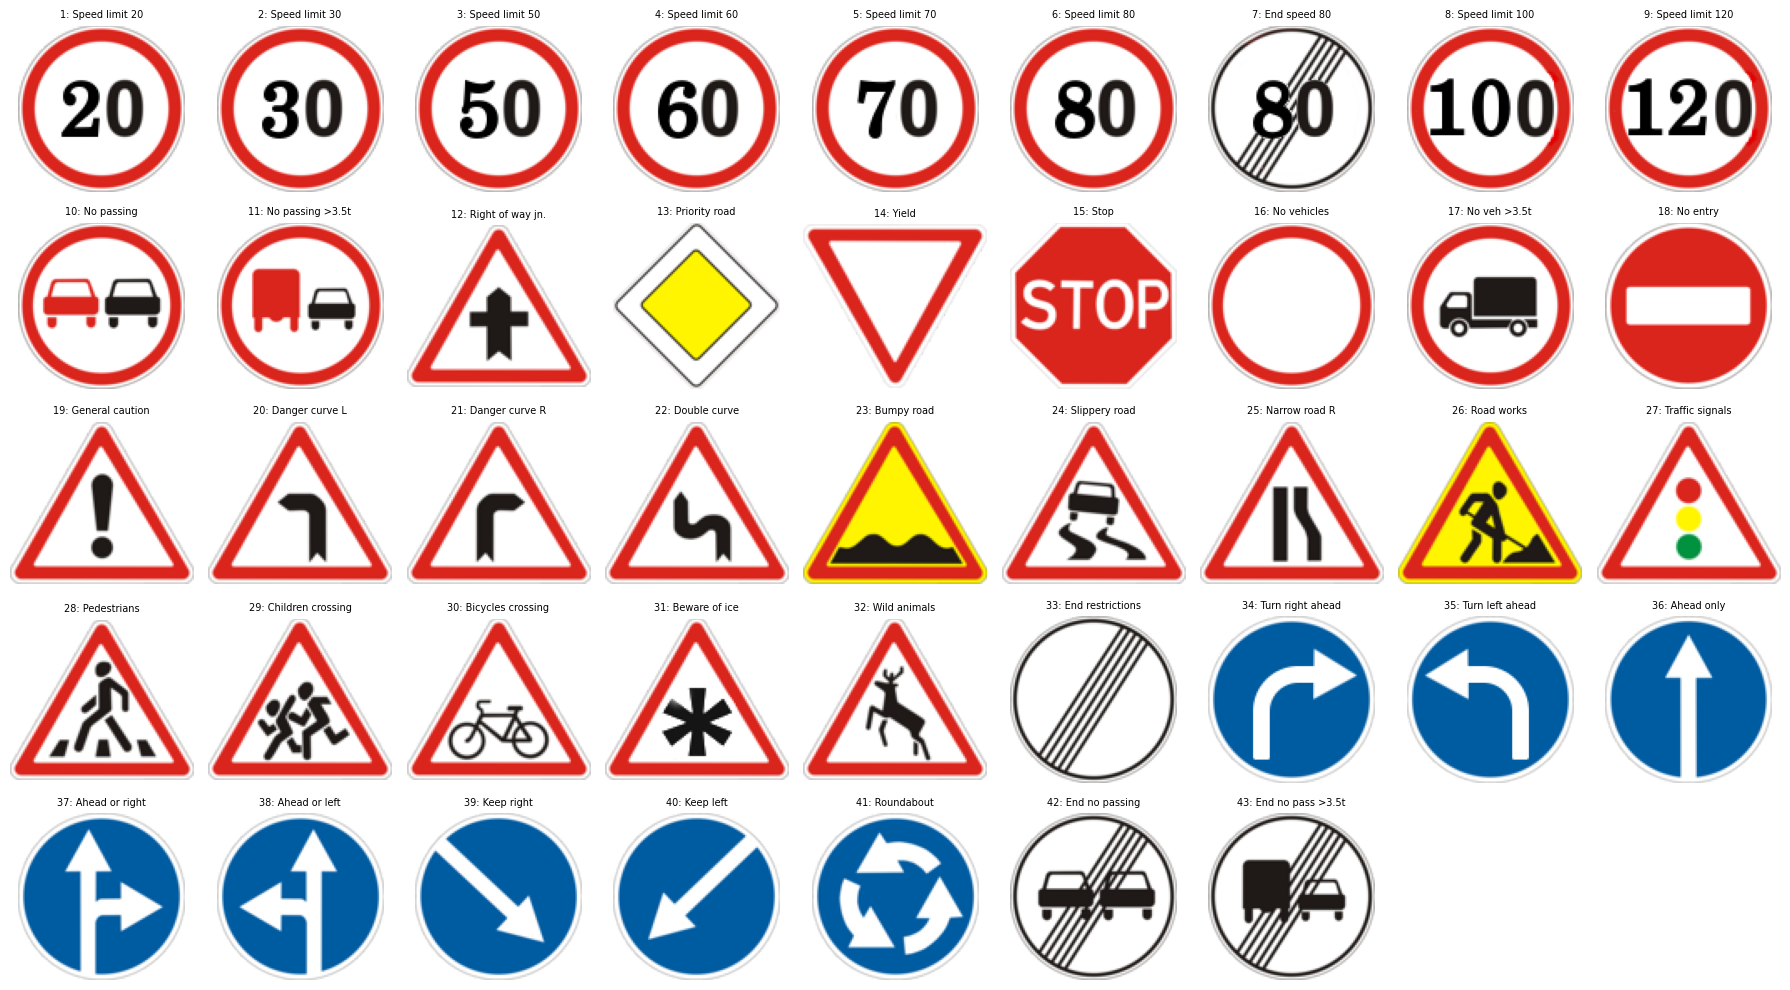

In [ ]:
meta_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-signظMeta"#path to the meta folder in the dataset

fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(43):  

    img_path = os.path.join(meta_path, f"{class_id}.png")

    img = Image.open(img_path)

    axes[class_id].imshow(img)
    axes[class_id].set_title(f"{class_id+1}: {CLASS_NAMES[class_id]}", fontsize=7)
    axes[class_id].axis("off")


for i in range(43, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


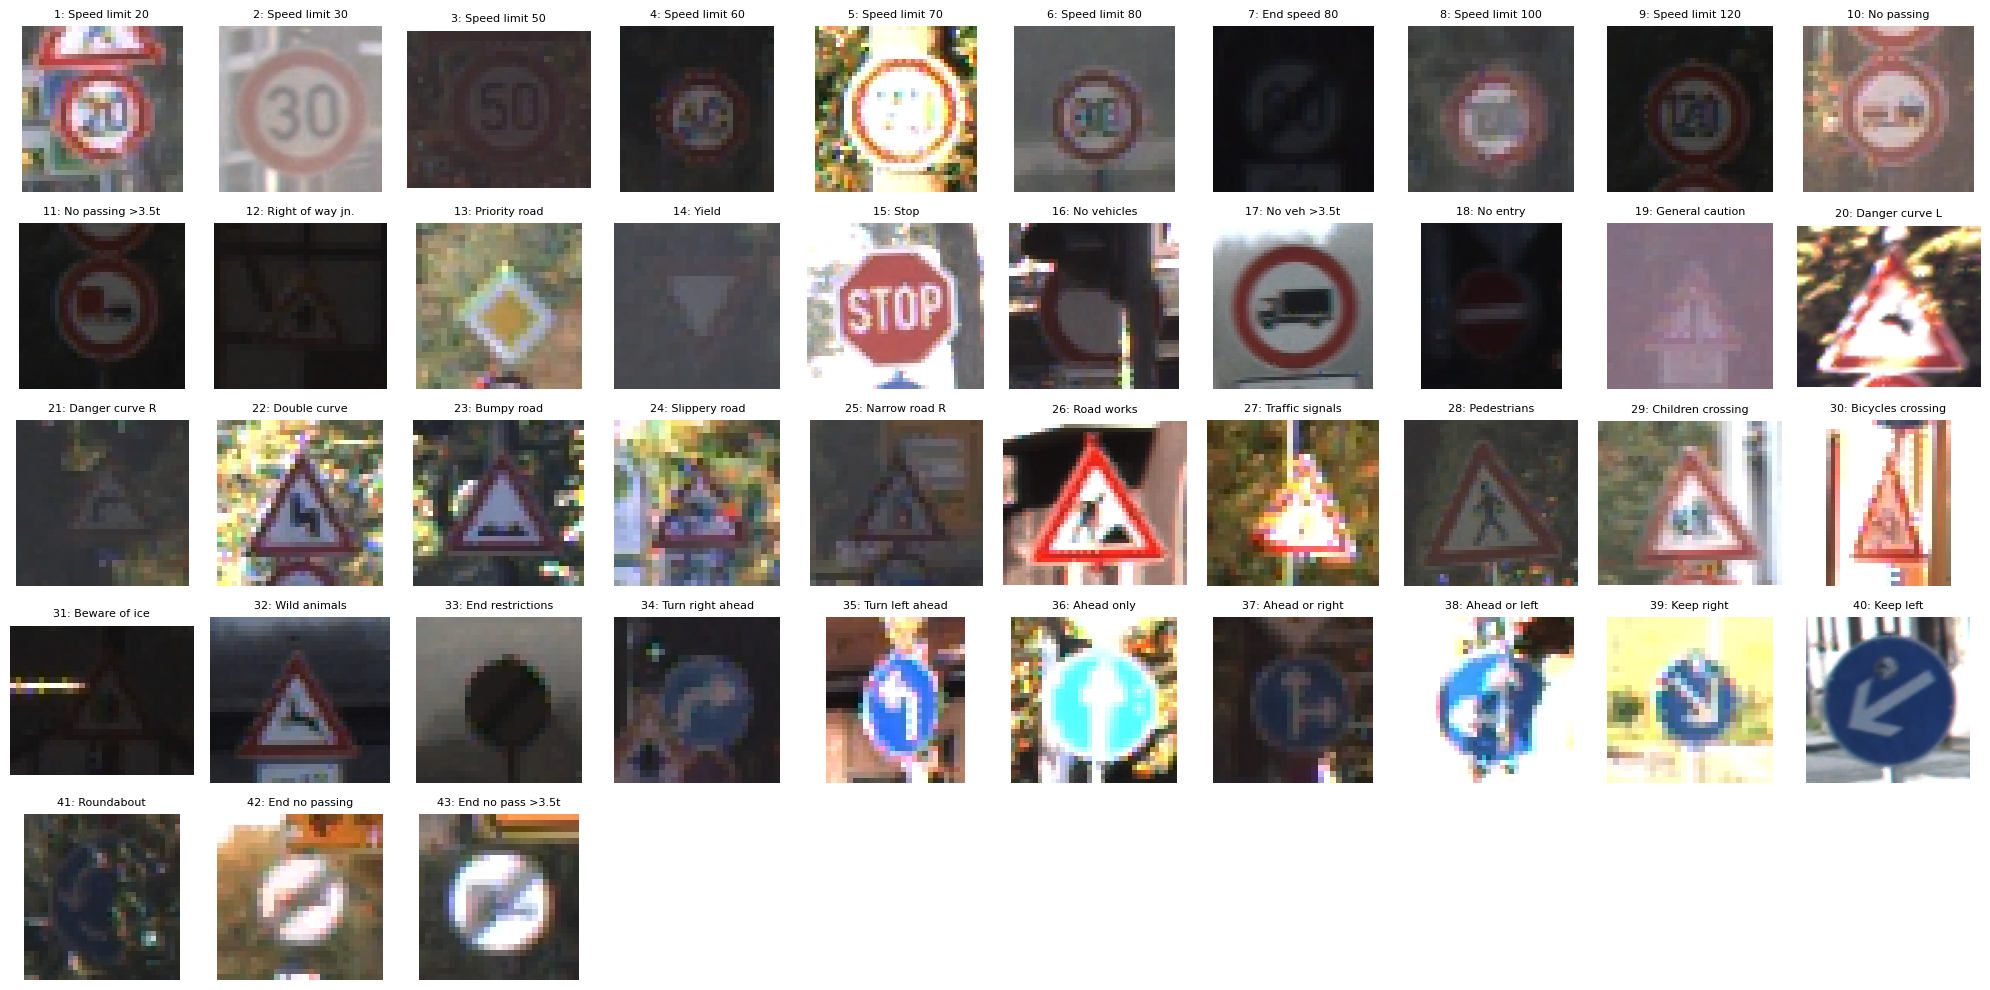

In [5]:
from PIL import Image
sample_df = train_df.groupby('label').first().reset_index()

n_samples = len(sample_df)

n_cols = 10
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i in range(n_samples):
    img = Image.open(sample_df['filepath'][i])
    
    label = sample_df['label'][i]
    class_name = CLASS_NAMES[label]
    
    axes[i].imshow(img)
    axes[i].set_title(f"{label+1}: {class_name}", fontsize=8)
    axes[i].axis('off')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

C:\Users\Shadow\AppData\Local\Temp\ipykernel_19288\2509191145.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


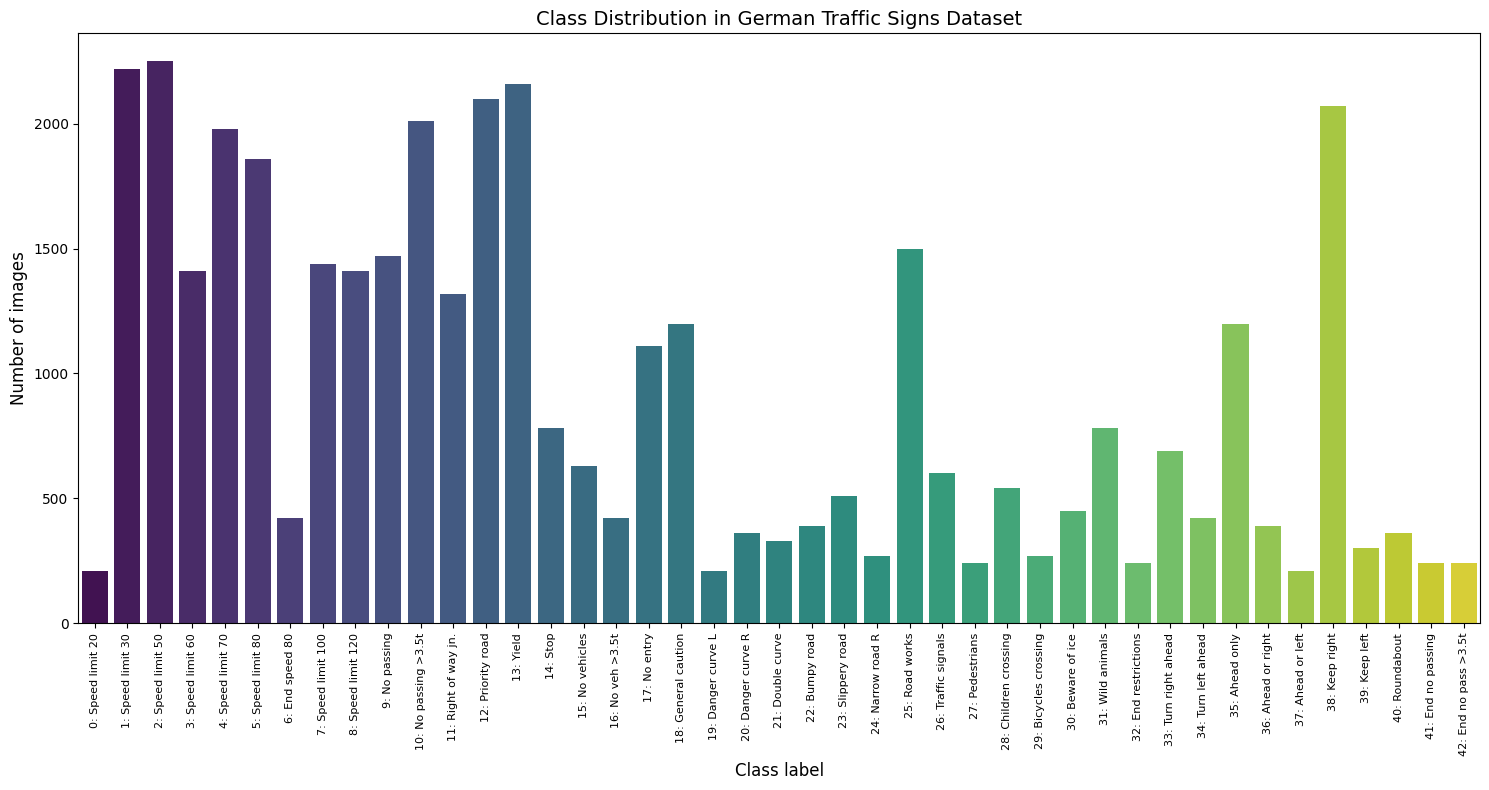

Total images: 39209
Total classes: 43
Average images per class: 911.84
Min images in a class: 210
Max images in a class: 2250


In [6]:

import matplotlib.pyplot as plt

class_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Class label', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Class Distribution in German Traffic Signs Dataset', fontsize=14)

plt.xticks(ticks=range(len(class_counts)), 
           labels=[f"{i}: {CLASS_NAMES[i]}" for i in class_counts.index], 
           rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total images: {len(train_df)}")
print(f"Total classes: {len(class_counts)}")
print(f"Average images per class: {len(train_df)/len(class_counts):.2f}")
print(f"Min images in a class: {class_counts.min()}")
print(f"Max images in a class: {class_counts.max()}")


In [7]:
from skimage.feature import hog
from skimage import color, exposure
from skimage.transform import resize

def preprocess_image(image_path, size=(32, 32)):
    img = Image.open(image_path)
    img_resized = img.resize(size)
    return np.array(img_resized)


#Extract edges and compute HOG features to capture shape and structure information, which is crucial for traffic sign recognition.
def extract_hog_features(image_array, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=8):
    img_gray = color.rgb2gray(image_array)
    fd = hog(img_gray, 
             orientations=orientations,
             pixels_per_cell=pixels_per_cell,
             cells_per_block=cells_per_block,
             block_norm='L2-Hys',
             transform_sqrt=True,
             feature_vector=True)
    return fd


x_train = []
for filepath in train_df['filepath']:
    img_array = preprocess_image(filepath)
    hog_features = extract_hog_features(img_array)
    x_train.append(hog_features)

x_train = np.array(x_train)


x_test = []
for filepath in test_df['filepath']:
    img_array = preprocess_image(filepath)
    hog_features = extract_hog_features(img_array)
    x_test.append(hog_features)

x_test = np.array(x_test)

y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Feature vector size: {x_train.shape[1]}")
print(f"Train: {x_train.shape[0]} | Test: {x_test.shape[0]}")

Feature vector size: 288
Train: 39209 | Test: 12630


In [8]:
# Standardize the flattened pixel values
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

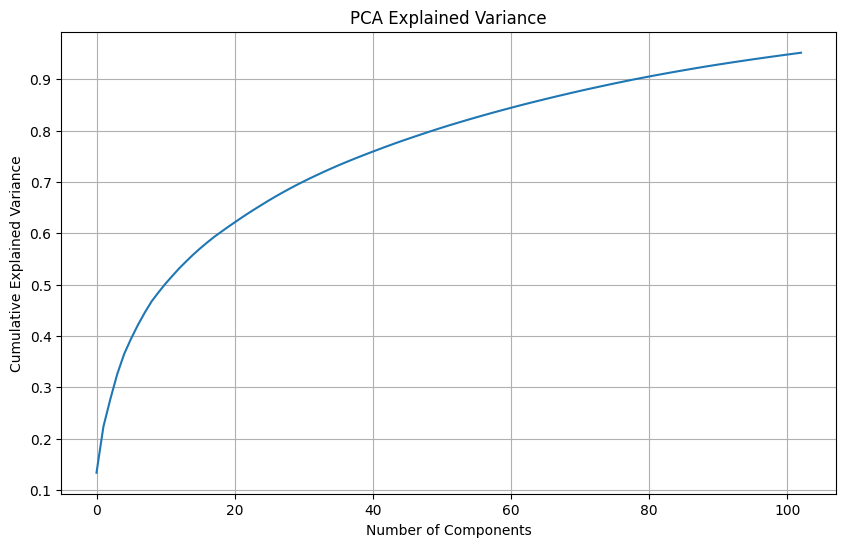

Components selected: 103


In [9]:
# Applying PCA for Dimensionality Reduction
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print(f"Components selected: {pca.n_components_}")

In [10]:
#KNN Without PCA
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train_scaled, y_train.reshape(-1,))
y_KNN = KNN.predict(x_test_scaled)
print("KNN without PCA Accuracy:", accuracy_score(y_test, y_KNN))

KNN without PCA Accuracy: 0.6876484560570071


In [11]:
#KNN with PCA
KNN_pca = KNeighborsClassifier(n_neighbors=5)
KNN_pca.fit(x_train_pca,y_train.reshape(-1,))
y_KNN_pca = KNN_pca.predict(x_test_pca)
print("KNN with PCA Accuracy:", accuracy_score(y_test, y_KNN_pca))

KNN with PCA Accuracy: 0.6878068091844813


In [12]:
# Naive Bayes without PCA
ModelNaive = GaussianNB()
ModelNaive.fit(x_train_scaled, y_train.reshape(-1,))
y_ModelNaive = ModelNaive.predict(x_test_scaled)
print("Naive Bayes without PCA Accuracy:", accuracy_score(y_test, y_ModelNaive))

Naive Bayes without PCA Accuracy: 0.6855106888361046


In [13]:
# Naive Bayes with PCA
ModelNaive_pca = GaussianNB()
ModelNaive_pca.fit(x_train_pca, y_train.reshape(-1,))
y_ModelNaive_pca = ModelNaive_pca.predict(x_test_pca)
print("Naive Bayes with PCA Accuracy:", accuracy_score(y_test, y_ModelNaive_pca))

Naive Bayes with PCA Accuracy: 0.728978622327791


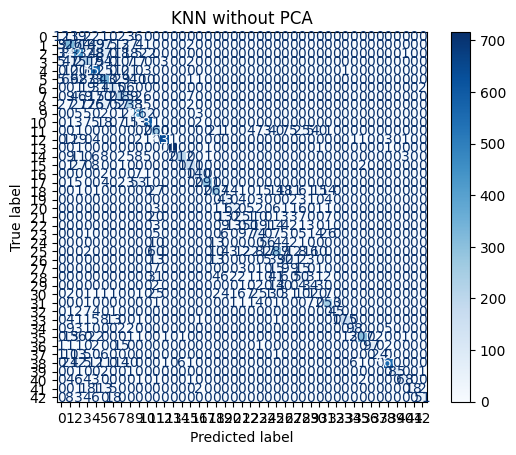

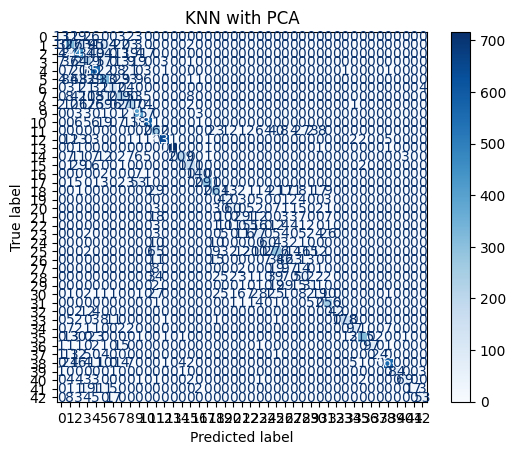

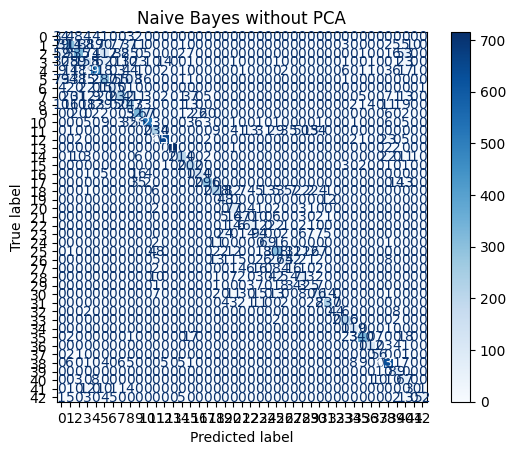

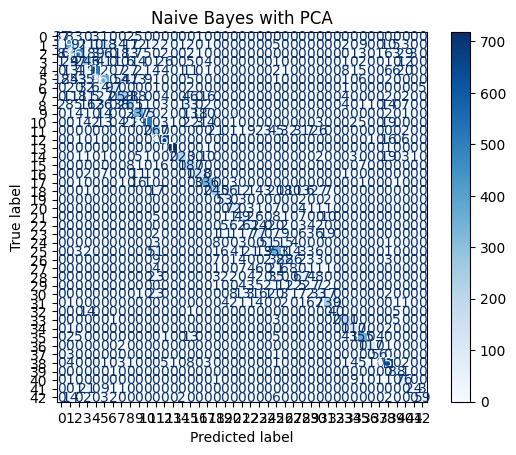

In [14]:
#Confusion Matrix
def confusion(y, y_pred , title):
    z= confusion_matrix(y, y_pred)
    d= ConfusionMatrixDisplay(confusion_matrix=z)
    d.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

confusion(y_test, y_KNN, "KNN without PCA")
confusion(y_test, y_KNN_pca, "KNN with PCA")

confusion(y_test, y_ModelNaive, "Naive Bayes without PCA")
confusion(y_test, y_ModelNaive_pca, "Naive Bayes with PCA")

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_train_normalized = scaler.fit_transform(x_train)
x_test_normalized = scaler.transform(x_test)


In [16]:
#NOISE
def gaussian_noise(features, noise_factor):
    noisy_features = features + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=features.shape)
    noisy_features = np.clip(noisy_features, 0., 1.)
    return noisy_features


#salt and peper noise 
def salt_peper(features, dropout_rate):
    noisy_features = np.copy(features)
    mask = np.random.binomial(1, 1 - dropout_rate, size=features.shape)
    noisy_features = noisy_features * mask
    return noisy_features

x_train_noisy = gaussian_noise(x_train_normalized, noise_factor=0.4)
x_train_noisy = salt_peper(x_train_noisy, dropout_rate=0.2)

x_test_noisy = gaussian_noise(x_test_normalized, noise_factor=0.4)
x_test_noisy = salt_peper(x_test_noisy, dropout_rate=0.2)



print(f"Noisy train features shape: {x_train_noisy.shape}")
print(f"Noisy test features shape: {x_test_noisy.shape}")

Noisy train features shape: (39209, 288)
Noisy test features shape: (12630, 288)


In [17]:
from tensorflow import keras
from tensorflow.keras import layers


def build_dense_autoencoder(input_dim):

    input_layer = layers.Input(shape=(input_dim,))
    
    # Encoding layers
    encoded = layers.Dense(256, activation='relu')(input_layer)
    encoded = layers.Dense(128, activation='relu')(encoded)
    encoded = layers.Dense(64, activation='relu')(encoded)  
    
    # Decoding layers
    decoded = layers.Dense(128, activation='relu')(encoded)
    decoded = layers.Dense(256, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)  
    
    autoencoder = keras.Model(input_layer, decoded)
    
    return autoencoder


feature_dim = x_train.shape[1]
autoencoder = build_dense_autoencoder(feature_dim)
autoencoder.summary()

# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='mse', 
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 288)            │        74,016 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,496 (900.38 KB)

 Trainable params: 230,496 (900.38 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = autoencoder.fit(
    x_train_noisy, x_train_normalized,  
    epochs=100,
    batch_size=120,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_normalized),
    verbose=1
)

Epoch 1/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0293 - val_loss: 0.0233
Epoch 2/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0222 - val_loss: 0.0218
Epoch 3/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0210 - val_loss: 0.0212
Epoch 4/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0203 - val_loss: 0.0210
Epoch 5/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0198 - val_loss: 0.0205
Epoch 6/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0194 - val_loss: 0.0203
Epoch 7/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0190 - val_loss: 0.0201
Epoch 8/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0187 - val_loss: 0.0200
Epoch 9/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0184 - val_loss: 0.0199
Epoch 10/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0181 - val_loss: 0.0198
Epoch 11/100
327/327 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0179 - val_loss: 0.0199
Epoch 12/100
327/327 ━━━━━━━━━━━━

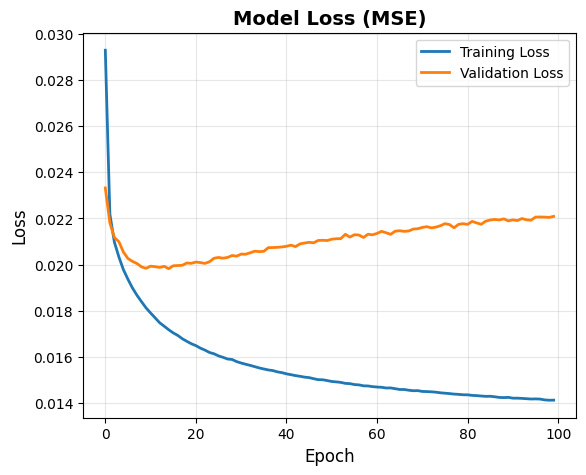

In [19]:
# Step 6: Plot Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)




Generating reconstructed features
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


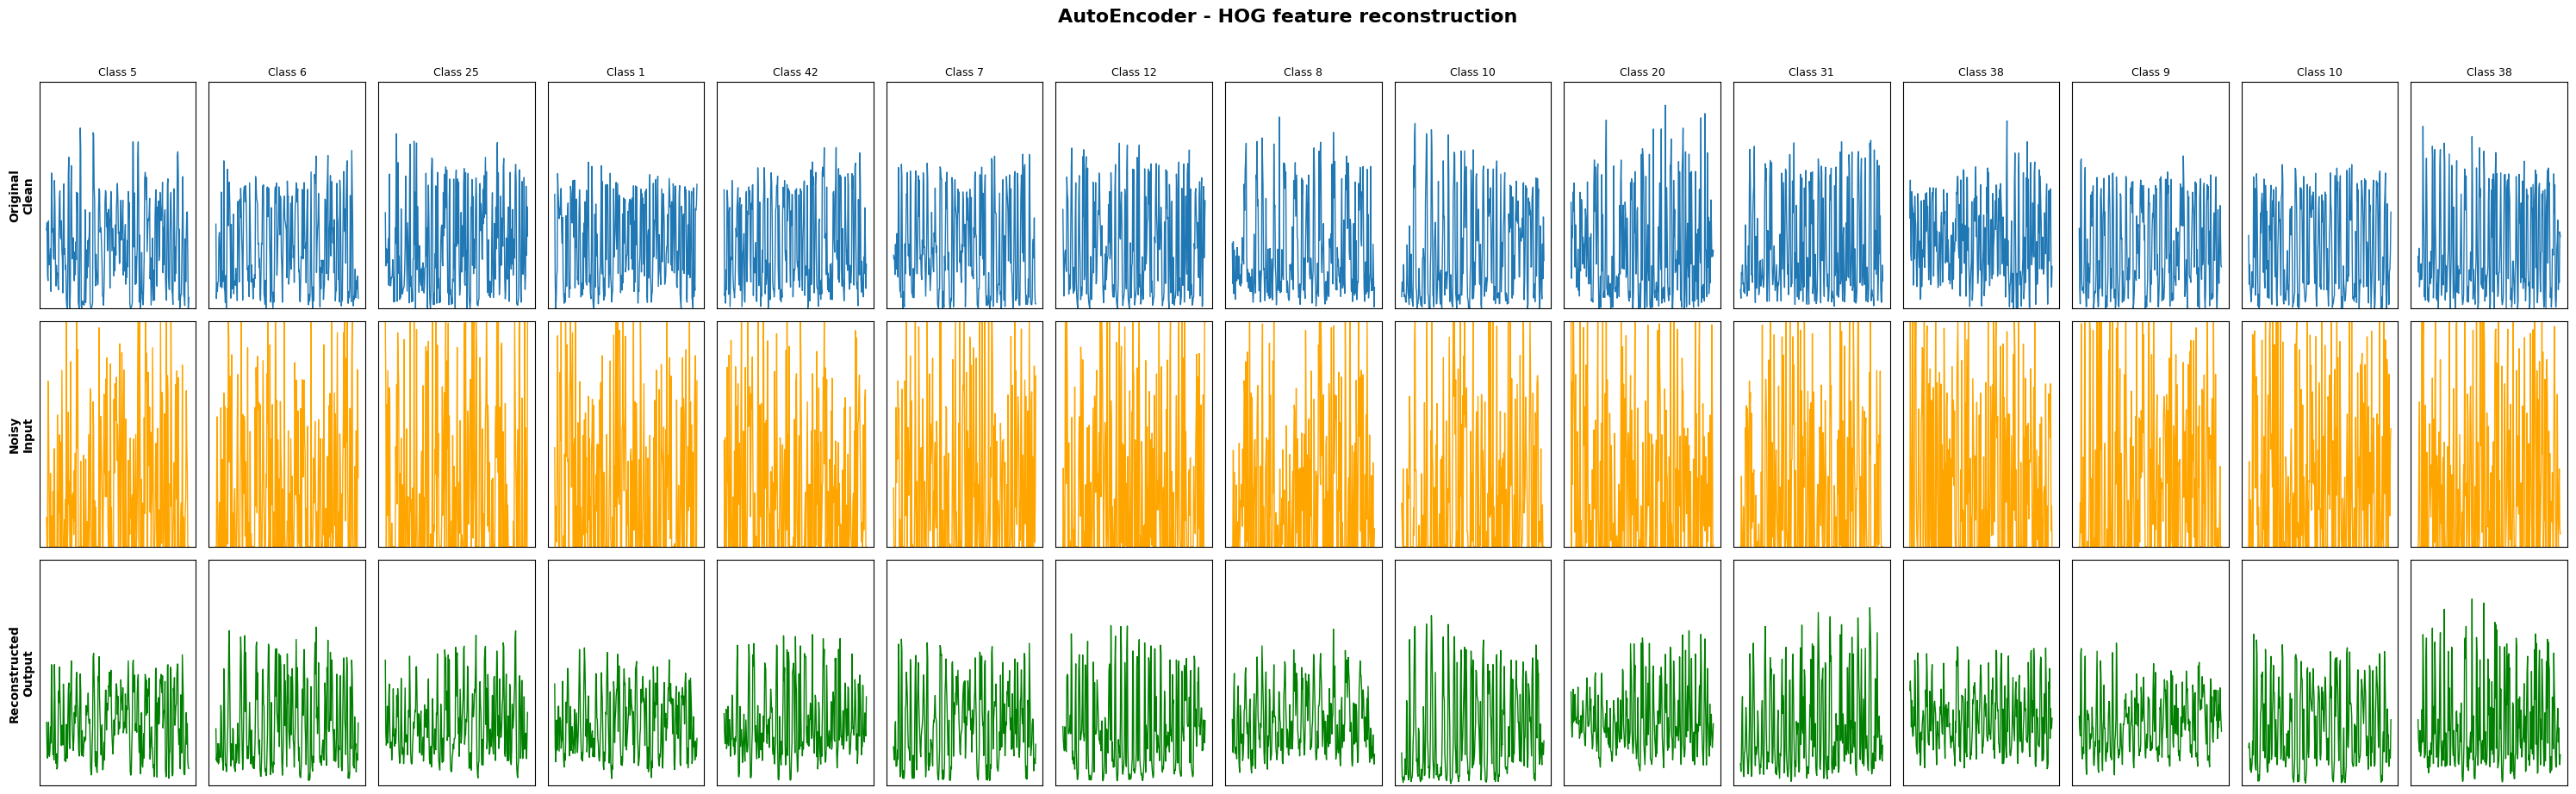

In [24]:
print("\nGenerating reconstructed features")
x_train_reconstructed = autoencoder.predict(x_train_noisy)
x_test_reconstructed = autoencoder.predict(x_test_noisy)

n_samples = 15
sample_indices = np.random.choice(len(x_test_normalized), n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(30, 9))

for i, idx in enumerate(sample_indices):
    #clean features
    axes[0, i].plot(x_test_normalized[idx], linewidth=1)
    axes[0, i].set_ylim([0, 1])
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    if i == 0:
        axes[0, i].set_ylabel('Original\nClean', fontsize=10, fontweight='bold')
    
    #Noisy features
    axes[1, i].plot(x_test_noisy[idx], linewidth=1, color='orange')
    axes[1, i].set_ylim([0, 1])
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    if i == 0:
        axes[1, i].set_ylabel('Noisy\nInput', fontsize=10, fontweight='bold')
    
    # Reconstructed Features
    axes[2, i].plot(x_test_reconstructed[idx], linewidth=1, color='green')
    axes[2, i].set_ylim([0, 1])
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])
    if i == 0:
        axes[2, i].set_ylabel('Reconstructed\nOutput', fontsize=10, fontweight='bold')
    
    axes[0, i].set_title(f'Class {y_test[idx]}', fontsize=9)

plt.suptitle('AutoEncoder - HOG feature reconstruction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mse_train = np.mean((x_train_normalized - x_train_reconstructed) ** 2)

mse_test = np.mean((x_test_normalized - x_test_reconstructed) ** 2)


In [23]:
print(f"\n{'='*60}")
print(f"PERFORMANCE - HOG feature Reconstruction")
print(f"{'='*60}")
print(f"Training Set:")
print(f"  Mean squared error : {mse_train:.6f}")
print(f"\nTest Set:")
print(f"  Mean squared error : {mse_test:.6f}")
print(f"{'='*60}")


PERFORMANCE - HOG feature Reconstruction
Training Set:
  Mean squared error : 0.013970

Test Set:
  Mean squared error : 0.022089
